# GAIA Level 1 (gaia_lv1_x3) — Execution-Trace Statistics

Analysis of the **baseline** execution traces in `traces/claude_native/gaia_lv1_x3/`
(original + 2 paraphrases per task, no plan reuse). Query embeddings are loaded
from the pre-computed `embeddings/claude_native/gaia_lv1_x3/` (768-d `all-mpnet-base-v2`).

Sections:
1. Scalar summary stats (step count / tokens / latency)
2. Tool-call frequency distribution
3. Top-10 tool sequences
4. Top-10 tool transitions (A → B)
5. Paraphrase embedding sanity check (within- vs across-group cosine)
6. Within-paraphrase-group variability of step/token/latency
7. Embedding similarity vs tool-representation similarity (paraphrase vs non-paraphrase)
8. Which structural metric correlates most with semantic similarity


In [1]:
%matplotlib inline
from pathlib import Path
import json, re
from collections import Counter, defaultdict
from difflib import SequenceMatcher
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

# Resolve repo root whether run from repo/ or repo/notebooks/
EKB_ROOT = Path.cwd()
if not (EKB_ROOT / "traces").exists() and (EKB_ROOT.parent / "traces").exists():
    EKB_ROOT = EKB_ROOT.parent
RUN = "gaia_lv1_x3"
TRACES_DIR = EKB_ROOT / "traces" / "claude_native" / RUN
EMB_DIR    = EKB_ROOT / "embeddings" / "claude_native" / RUN
print("EKB_ROOT  :", EKB_ROOT)
print("traces    :", TRACES_DIR, "| exists:", TRACES_DIR.exists())
print("embeddings:", EMB_DIR, "| exists:", EMB_DIR.exists())


EKB_ROOT  : /Users/tungi/ekb-claude-pilot
traces    : /Users/tungi/ekb-claude-pilot/traces/claude_native/gaia_lv1_x3 | exists: True
embeddings: /Users/tungi/ekb-claude-pilot/embeddings/claude_native/gaia_lv1_x3 | exists: True


In [2]:
# ---- Load normalized traces ----
def variant_of(tid):
    m = re.search(r"__para(\d+)$", tid)
    return f"paraphrase_{m.group(1)}" if m else "original"
def source_of(tid):
    return re.sub(r"__para\d+$", "", tid)

rows = []
for tdir in sorted(TRACES_DIR.glob("*")):
    f = tdir / "normalized_trace.json"
    if not f.exists():
        continue
    t = json.loads(f.read_text())
    tid = t["query_id"]
    seq = [s["tool"] for s in (t.get("steps") or []) if s.get("tool")]
    rows.append(dict(
        task_id=tid, source_id=source_of(tid), variant=variant_of(tid),
        query_text=t.get("query_text"),
        total_steps=t.get("total_steps"),
        total_tokens=t.get("total_tokens"),
        total_latency_ms=t.get("total_latency_ms"),
        latency_s=(t.get("total_latency_ms") or np.nan) / 1000.0,
        n_tools=len(seq),
        tools_used=tuple(sorted(set(seq))),
        tool_sequence=tuple(seq),
        has_answer=bool(t.get("final_answer_pred") and str(t.get("final_answer_pred")).strip()),
        exact_match=t.get("exact_match"),
    ))
df = pd.DataFrame(rows)
print(f"{len(df)} traces | {df.source_id.nunique()} paraphrase groups | "
      f"{df.has_answer.sum()} with answer, {(~df.has_answer).sum()} without")
df.head(3)


150 traces | 51 paraphrase groups | 150 with answer, 0 without


,task_id,source_id,variant,query_text,total_steps,total_tokens,total_latency_ms,latency_s,n_tools,tools_used,tool_sequence,has_answer,exact_match
0,0383a3ee-47a7-41a4-b493-519bdefe0488,0383a3ee-47a7-41a4-b493-519bdefe0488,original,On the BBC Earth YouTube video of the Top 5 Si...,8,250310,45707,45.707,8,"(StructuredOutput, ToolSearch, WebFetch, WebSe...","(ToolSearch, WebSearch, ToolSearch, WebFetch, ...",True,True
1,0383a3ee-47a7-41a4-b493-519bdefe0488__para1,0383a3ee-47a7-41a4-b493-519bdefe0488,paraphrase_1,In the BBC Earth YouTube video titled 'Top 5 S...,3,106291,16825,16.825,3,"(StructuredOutput, ToolSearch, WebSearch)","(ToolSearch, WebSearch, StructuredOutput)",True,False
2,0383a3ee-47a7-41a4-b493-519bdefe0488__para2,0383a3ee-47a7-41a4-b493-519bdefe0488,paraphrase_2,Which species of bird is shown in the BBC Eart...,5,163290,24646,24.646,5,"(StructuredOutput, ToolSearch, WebFetch, WebSe...","(ToolSearch, WebSearch, ToolSearch, WebFetch, ...",True,False


## 1. Scalar summary stats — step count / token use / latency

,n,mean,median,p75,max,min,std
step_count,150.0,6.15,5.00,7.00,39.00,1.00,6.93
total_tokens,150.0,223756.98,163550.00,251715.50,1403418.00,51484.00,247042.66
latency_s,150.0,94.70,37.69,70.03,842.93,6.46,157.93


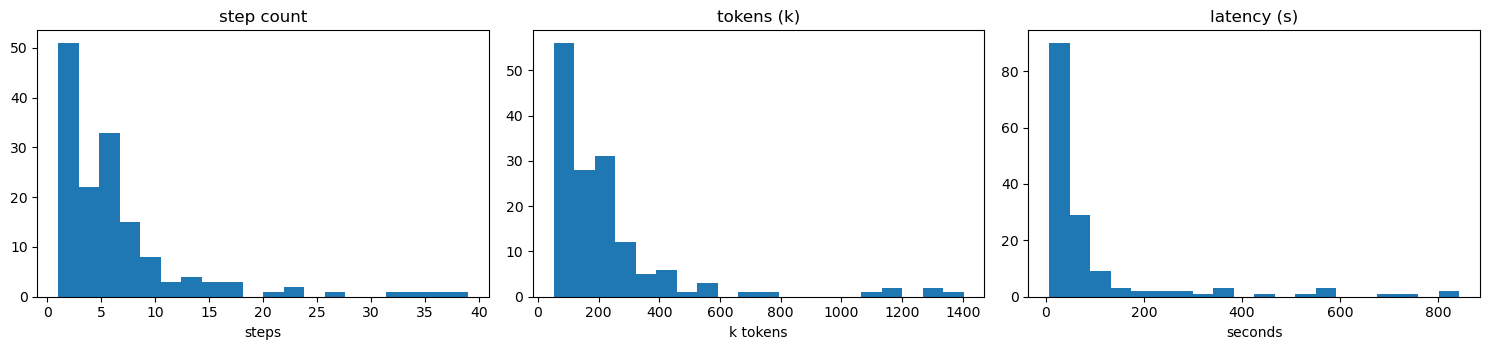

In [3]:
def summarize(s):
    s = pd.Series(s).dropna()
    return dict(n=len(s), mean=s.mean(), median=s.median(),
                p75=s.quantile(0.75), max=s.max(), min=s.min(), std=s.std())

summary = pd.DataFrame({
    "step_count":   summarize(df.total_steps),
    "total_tokens": summarize(df.total_tokens),
    "latency_s":    summarize(df.latency_s),
}).T[["n", "mean", "median", "p75", "max", "min", "std"]]
display(summary.round(2))

fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
ax[0].hist(df.total_steps.dropna(), bins=20);                ax[0].set_title("step count");   ax[0].set_xlabel("steps")
ax[1].hist(df.total_tokens.dropna()/1000, bins=20);          ax[1].set_title("tokens (k)");    ax[1].set_xlabel("k tokens")
ax[2].hist(df.latency_s.dropna(), bins=20);                  ax[2].set_title("latency (s)");   ax[2].set_xlabel("seconds")
plt.tight_layout(); plt.show()


## 2. Tool-call frequency distribution

,tool,calls,pct_of_calls,n_tasks_using,pct_tasks
0,WebFetch,347,37.6,71,47.3
1,WebSearch,185,20.0,76,50.7
2,StructuredOutput,150,16.3,150,100.0
3,ToolSearch,142,15.4,81,54.0
4,Bash,76,8.2,29,19.3
5,Read,13,1.4,13,8.7
6,Agent,6,0.7,1,0.7
7,Grep,3,0.3,2,1.3
8,Glob,1,0.1,1,0.7


MOST frequent tool : WebFetch  (347 calls)
LEAST frequent tool: Glob  (1 calls)


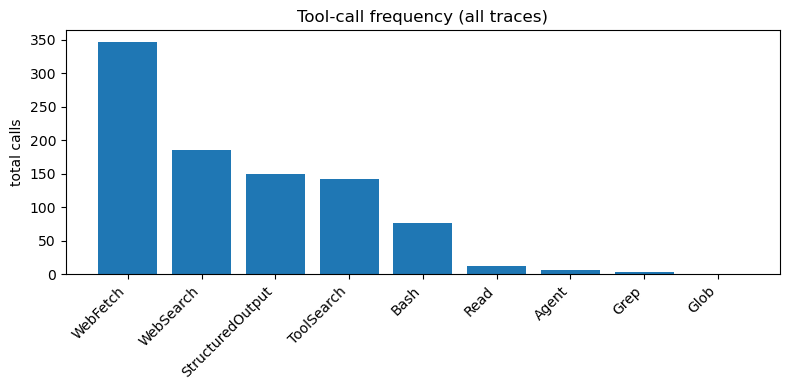

In [4]:
tool_calls = Counter()
for seq in df.tool_sequence:
    tool_calls.update(seq)
tasks_using = Counter()
for tu in df.tools_used:
    tasks_using.update(tu)

freq = (pd.DataFrame([{"tool": k, "calls": v} for k, v in tool_calls.items()])
        .sort_values("calls", ascending=False).reset_index(drop=True))
freq["pct_of_calls"]  = (freq.calls / freq.calls.sum() * 100).round(1)
freq["n_tasks_using"] = freq.tool.map(tasks_using)
freq["pct_tasks"]     = (freq.n_tasks_using / len(df) * 100).round(1)
display(freq)
print(f"MOST frequent tool : {freq.iloc[0].tool}  ({freq.iloc[0].calls} calls)")
print(f"LEAST frequent tool: {freq.iloc[-1].tool}  ({freq.iloc[-1].calls} calls)")

plt.figure(figsize=(8, 4))
plt.bar(freq.tool, freq.calls)
plt.xticks(rotation=45, ha="right"); plt.ylabel("total calls"); plt.title("Tool-call frequency (all traces)")
plt.tight_layout(); plt.show()


## 3. Top-10 most frequent tool sequences

In [5]:
seq_counter = Counter(df.tool_sequence)
top_seq = pd.DataFrame(
    [{"rank": i+1, "count": c, "len": len(s), "sequence": " → ".join(s) if s else "(empty)"}
     for i, (s, c) in enumerate(seq_counter.most_common(10))]
)
display(top_seq)
print(f"{len(seq_counter)} distinct tool sequences across {len(df)} traces")


,rank,count,len,sequence
0,1,39,1,StructuredOutput
1,2,11,6,ToolSearch → WebSearch → ToolSearch → WebFetch...
2,3,9,3,Bash → Bash → StructuredOutput
3,4,8,3,ToolSearch → WebSearch → StructuredOutput
4,5,8,5,ToolSearch → WebSearch → ToolSearch → WebFetch...
5,6,7,2,Read → StructuredOutput
6,7,5,2,Bash → StructuredOutput
7,8,3,7,ToolSearch → WebSearch → ToolSearch → WebFetch...
8,9,3,7,ToolSearch → WebSearch → ToolSearch → WebFetch...
9,10,3,6,ToolSearch → WebFetch → WebFetch → WebFetch → ...


59 distinct tool sequences across 150 traces


## 4. Top-10 most frequent tool transitions (A → B)

In [6]:
trans = Counter()
for seq in df.tool_sequence:
    for a, b in zip(seq, seq[1:]):
        trans[(a, b)] += 1
top_trans = pd.DataFrame(
    [{"rank": i+1, "transition": f"{a} → {b}", "count": c}
     for i, ((a, b), c) in enumerate(trans.most_common(10))]
)
display(top_trans)
print(f"{len(trans)} distinct transitions; {sum(trans.values())} total transitions")


,rank,transition,count
0,1,WebFetch → WebFetch,201
1,2,WebFetch → WebSearch,82
2,3,WebSearch → WebFetch,74
3,4,ToolSearch → WebSearch,71
4,5,ToolSearch → WebFetch,70
5,6,WebSearch → ToolSearch,58
6,7,WebFetch → StructuredOutput,54
7,8,Bash → Bash,43
8,9,WebSearch → WebSearch,30
9,10,Bash → StructuredOutput,24


29 distinct transitions; 773 total transitions


## Load query embeddings (pre-computed, 768-d all-mpnet-base-v2)
Aligned to the traces; rows are L2-normalized so dot product = cosine similarity.

In [7]:
emb = {}
for tid in df.task_id:
    p = EMB_DIR / tid / "query_embedding.npy"
    if p.exists():
        emb[tid] = np.load(p).astype(np.float64)

dfe = df[df.task_id.isin(emb)].reset_index(drop=True)
E = np.stack([emb[t] for t in dfe.task_id])
E = E / np.linalg.norm(E, axis=1, keepdims=True)
S = E @ E.T  # full cosine-similarity matrix
src = dfe.source_id.values
print(f"{len(dfe)}/{len(df)} traces have embeddings | matrix {E.shape}")


150/150 traces have embeddings | matrix (150, 768)


## 5. Sanity check — paraphrases have near-identical embeddings
Compare cosine similarity of **within-group** pairs (paraphrases of the same task)
vs **across-group** pairs (arbitrary two queries).

,within-group (paraphrases),across-group (arbitrary)
n_pairs,148.000,11027.000
mean_cos,0.911,0.119
median_cos,0.926,0.110
std,0.058,0.093
min,0.650,-0.141
max,0.985,0.709


separation (mean within - mean across) = 0.793


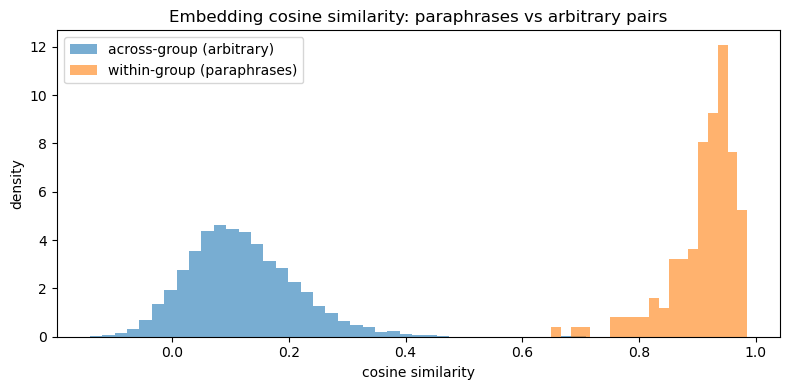

In [8]:
n = len(dfe)
within, across = [], []
for i in range(n):
    for j in range(i+1, n):
        (within if src[i] == src[j] else across).append(S[i, j])
within, across = np.array(within), np.array(across)

tbl = pd.DataFrame({
    "within-group (paraphrases)": [len(within), within.mean(), np.median(within), within.std(), within.min(), within.max()],
    "across-group (arbitrary)":   [len(across), across.mean(), np.median(across), across.std(), across.min(), across.max()],
}, index=["n_pairs", "mean_cos", "median_cos", "std", "min", "max"])
display(tbl.round(3))
print(f"separation (mean within - mean across) = {within.mean() - across.mean():.3f}")

plt.figure(figsize=(8, 4))
plt.hist(across, bins=40, alpha=0.6, density=True, label="across-group (arbitrary)")
plt.hist(within, bins=20, alpha=0.6, density=True, label="within-group (paraphrases)")
plt.xlabel("cosine similarity"); plt.ylabel("density"); plt.legend()
plt.title("Embedding cosine similarity: paraphrases vs arbitrary pairs")
plt.tight_layout(); plt.show()


## 6. Within-paraphrase-group variability of execution
How differently are semantically-identical queries executed? Per group we take the
std of each metric, then average those stds across groups (groups with >=2 traces).
Compared against the global std for context (ratio < 1 ⇒ paraphrases are more
consistent than the population).

,metric,n_groups,mean_within_group_std,median_within_group_std,global_std,ratio_within_over_global
0,step_count,50,1.937,0.577,6.927,0.280
1,total_tokens,50,72753.885,17969.868,247042.659,0.294
2,latency_s,50,41.018,7.694,157.926,0.260


group sizes: {3: 49, 2: 1, 1: 1}  (groups used for std: size>=2)


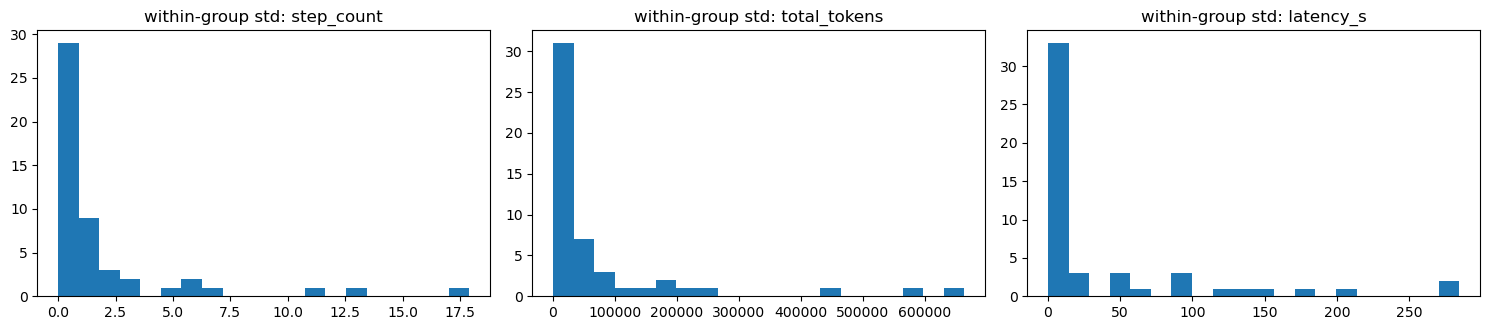

Tool-transition frequency-vector cosine — within paraphrase groups vs arbitrary pairs:


,within-group (paraphrases),across-group (arbitrary)
n_pairs,148.000,11027.000
mean_cos,0.598,0.161
median_cos,0.811,0.000
std,0.409,0.286


separation (within - across) = 0.437  (higher within ⇒ paraphrases transition between tools alike)


In [9]:
metrics = {"step_count": "total_steps", "total_tokens": "total_tokens", "latency_s": "latency_s"}
out = []
for name, col in metrics.items():
    g = df.groupby("source_id")[col].std()      # within-group std (NaN for singletons)
    g = g.dropna()
    out.append(dict(metric=name,
                    n_groups=len(g),
                    mean_within_group_std=g.mean(),
                    median_within_group_std=g.median(),
                    global_std=df[col].std(),
                    ratio_within_over_global=g.mean() / df[col].std()))
wg = pd.DataFrame(out)
display(wg.round(3))

sizes = df.groupby("source_id").size()
print(f"group sizes: {dict(Counter(sizes))}  (groups used for std: size>=2)")

fig, ax = plt.subplots(1, 3, figsize=(15, 3.4))
for k, (name, col) in enumerate(metrics.items()):
    g = df.groupby("source_id")[col].std().dropna()
    ax[k].hist(g, bins=20); ax[k].set_title(f"within-group std: {name}")
plt.tight_layout(); plt.show()

# --- tool-transition consistency: do paraphrases share tool-transition frequencies? ---
bv6 = sorted({(a, b) for s in df.tool_sequence for a, b in zip(s, s[1:])})
bi6 = {bg: i for i, bg in enumerate(bv6)}
def _tvec(s):
    v = np.zeros(max(len(bv6), 1))
    for a, b in zip(s, s[1:]): v[bi6[(a, b)]] += 1
    return v
def _cos(a, b):
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    return float(a @ b / (na * nb)) if na > 0 and nb > 0 else 0.0
TV = {t: _tvec(s) for t, s in zip(df.task_id, df.tool_sequence)}
ids6 = list(df.task_id); src6 = dict(zip(df.task_id, df.source_id))
win_tr, acr_tr = [], []
for x in range(len(ids6)):
    for y in range(x + 1, len(ids6)):
        c = _cos(TV[ids6[x]], TV[ids6[y]])
        (win_tr if src6[ids6[x]] == src6[ids6[y]] else acr_tr).append(c)
win_tr, acr_tr = np.array(win_tr), np.array(acr_tr)
trtab = pd.DataFrame({
    "within-group (paraphrases)": [len(win_tr), win_tr.mean(), np.median(win_tr), win_tr.std()],
    "across-group (arbitrary)":   [len(acr_tr), acr_tr.mean(), np.median(acr_tr), acr_tr.std()],
}, index=["n_pairs", "mean_cos", "median_cos", "std"])
print("Tool-transition frequency-vector cosine — within paraphrase groups vs arbitrary pairs:")
display(trtab.round(3))
print(f"separation (within - across) = {win_tr.mean() - acr_tr.mean():.3f}  "
      f"(higher within ⇒ paraphrases transition between tools alike)")


## 7. Embedding similarity vs tool-representation similarity
For every pair of queries we compute embedding cosine similarity and the similarity of
**four execution representations** (one per trace feature):
- **toolset_binary_cos** — cosine of multi-hot used-tool-set vectors (tool **set**)
- **toolcount_cos** — cosine of per-tool call-count vectors (tool **count**)
- **transition_cos** — cosine of tool-transition (A→B bigram) count vectors (tool **transition**)
- **seq_ratio** — `difflib` sequence-similarity ratio of the tool sequences (tool **sequence**)

We then (a) report the Pearson correlation of each with embedding similarity over all
pairs, and (b) contrast the mean similarity for **paraphrase** vs **non-paraphrase** pairs.

In [10]:
vocab = sorted({tool for seq in dfe.tool_sequence for tool in seq})
vidx = {t: i for i, t in enumerate(vocab)}
def binvec(seq):
    v = np.zeros(len(vocab));  [v.__setitem__(vidx[t], 1) for t in set(seq)];  return v
def countvec(seq):
    v = np.zeros(len(vocab))
    for t in seq: v[vidx[t]] += 1
    return v
def cos(a, b):
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    return float(a @ b / (na * nb)) if na > 0 and nb > 0 else 0.0

B = np.stack([binvec(s) for s in dfe.tool_sequence])
C = np.stack([countvec(s) for s in dfe.tool_sequence])
seqs = list(dfe.tool_sequence)

# tool-transition (A->B bigram) count vectors
bv7 = sorted({(a, b) for s in seqs for a, b in zip(s, s[1:])})
bi7 = {bg: i for i, bg in enumerate(bv7)}
def transvec7(s):
    v = np.zeros(max(len(bv7), 1))
    for a, b in zip(s, s[1:]): v[bi7[(a, b)]] += 1
    return v
Tr = np.stack([transvec7(s) for s in seqs])

emb_sim, ts_bin, ts_cnt, tr_cos, sq, is_para = [], [], [], [], [], []
for i in range(n):
    for j in range(i+1, n):
        emb_sim.append(S[i, j])
        ts_bin.append(cos(B[i], B[j]))
        ts_cnt.append(cos(C[i], C[j]))
        tr_cos.append(cos(Tr[i], Tr[j]))
        sq.append(SequenceMatcher(None, seqs[i], seqs[j]).ratio())
        is_para.append(src[i] == src[j])
P = pd.DataFrame(dict(emb_sim=emb_sim, toolset_binary_cos=ts_bin, toolcount_cos=ts_cnt,
                      transition_cos=tr_cos, seq_ratio=sq, is_para=is_para))

reps = ["toolset_binary_cos", "toolcount_cos", "transition_cos", "seq_ratio"]
print("Pearson correlation with embedding similarity (ALL pairs):")
for rep in reps:
    r, _ = pearsonr(P.emb_sim, P[rep])
    print(f"  {rep:20s}: r = {r:+.3f}")

print("\nMean similarity — paraphrase vs non-paraphrase pairs:")
display(P.groupby(P.is_para.map({True: "paraphrase", False: "non-paraphrase"}))
          [["emb_sim"] + reps].mean().round(3))


Pearson correlation with embedding similarity (ALL pairs):
  toolset_binary_cos  : r = +0.318
  toolcount_cos       : r = +0.321
  transition_cos      : r = +0.325
  seq_ratio           : r = +0.304

Mean similarity — paraphrase vs non-paraphrase pairs:


,emb_sim,toolset_binary_cos,toolcount_cos,transition_cos,seq_ratio
is_para,,,,,
non-paraphrase,0.119,0.657,0.481,0.161,0.438
paraphrase,0.911,0.971,0.952,0.598,0.866


## 8. Which structural metric is most correlated with semantic similarity?
We correlate many pairwise structural similarities against embedding cosine similarity
(Pearson + Spearman over all query pairs). Each metric targets one of four **trace
features** — tool **set**, tool **count**, tool **transition**, tool **sequence**
(bars in the plot are colored by feature).

**Notation.** For two traces $a,b$ over tool vocabulary $V$:
$S_x$ = set of tools used; $\mathbf{c}_x\in\mathbb{Z}_{\ge 0}^{|V|}$ = tool-count vector
($c_{x,v}$ = #calls of tool $v$); $\mathbf{u}_x\in\{0,1\}^{|V|}$ = binary used-tool vector;
$\mathbf{t}_x$ = transition (A→B bigram) count vector with transition set $\mathcal{T}_x$;
$\sigma_x$ = ordered tool sequence, length $|\sigma_x|$. Primed symbols
($S'_x,\mathbf{t}'_x,\sigma'_x$) are **substantive** versions with scaffolding tools
$\{$ToolSearch, StructuredOutput$\}$ removed. Helpers:
$\cos(\mathbf{x},\mathbf{y})=\dfrac{\mathbf{x}\cdot\mathbf{y}}{\lVert\mathbf{x}\rVert\,\lVert\mathbf{y}\rVert}$,
$\;\;J(A,B)=\dfrac{|A\cap B|}{|A\cup B|}$.

**Tool set**
- `toolset_jaccard` $= J(S_a,S_b)$
- `toolset_binary_cosine` $= \cos(\mathbf{u}_a,\mathbf{u}_b)=\dfrac{|S_a\cap S_b|}{\sqrt{|S_a|\,|S_b|}}$
- `toolset_jaccard_substantive` $= J(S'_a,S'_b)$

**Tool count**
- `toolcount_cosine` $= \cos(\mathbf{c}_a,\mathbf{c}_b)$
- `toolcount_manhattan` $= \dfrac{1}{1+\lVert\mathbf{c}_a-\mathbf{c}_b\rVert_1}$
- `toolcount_tfidf_cosine` $= \cos(\mathbf{c}_a\odot\boldsymbol{\phi},\,\mathbf{c}_b\odot\boldsymbol{\phi}),\;\; \phi_v=\ln\dfrac{N+1}{\mathrm{df}_v+1}+1$
- `toolcount_weighted_jaccard` $= \dfrac{\sum_v \min(c_{a,v},c_{b,v})}{\sum_v \max(c_{a,v},c_{b,v})}$
- `toolcount_braycurtis` $= 1-\dfrac{\sum_v |c_{a,v}-c_{b,v}|}{\sum_v (c_{a,v}+c_{b,v})}$

**Tool transition**
- `sequence_transition_cosine` $= \cos(\mathbf{t}_a,\mathbf{t}_b)$
- `transition_jaccard` $= J(\mathcal{T}_a,\mathcal{T}_b)$
- `transition_cosine_substantive` $= \cos(\mathbf{t}'_a,\mathbf{t}'_b)$

**Tool sequence**
- `sequence_levenshtein` $= 1-\dfrac{\mathrm{lev}(\sigma_a,\sigma_b)}{\max(|\sigma_a|,|\sigma_b|)}$
- `seq_levenshtein_substantive` $= 1-\dfrac{\mathrm{lev}(\sigma'_a,\sigma'_b)}{\max(|\sigma'_a|,|\sigma'_b|)}$
- `seq_lcs_ratio` $= \dfrac{2\,\mathrm{LCS}(\sigma_a,\sigma_b)}{|\sigma_a|+|\sigma_b|}$
- `seq_ratio_difflib` $= \dfrac{2M}{|\sigma_a|+|\sigma_b|}$ (Ratcliff–Obershelp; $M$ = #matched elements)


,metric,family,pearson_r,spearman_r,original
0,toolcount_tfidf_cosine,tool count,0.331,0.282,False
1,toolset_jaccard,tool set,0.330,0.309,True
2,sequence_transition_cosine,tool transition,0.325,0.307,True
3,toolset_jaccard_substantive,tool set,0.323,0.319,False
4,toolcount_cosine,tool count,0.321,0.293,True
5,toolset_binary_cosine,tool set,0.318,0.303,True
6,transition_jaccard,tool transition,0.312,0.310,False
7,seq_levenshtein_substantive,tool sequence,0.310,0.311,False
8,toolcount_braycurtis,tool count,0.310,0.281,False
9,seq_lcs_ratio,tool sequence,0.307,0.277,False



Best indicator: toolcount_tfidf_cosine  [tool count]  (Pearson r = 0.331, Spearman = 0.282)
Best of the ORIGINAL six: toolset_jaccard (r = 0.330)

Best metric per trace feature:
  tool set        : toolset_jaccard                  r = 0.330
  tool count      : toolcount_tfidf_cosine           r = 0.331
  tool transition : sequence_transition_cosine       r = 0.325
  tool sequence   : seq_levenshtein_substantive      r = 0.310


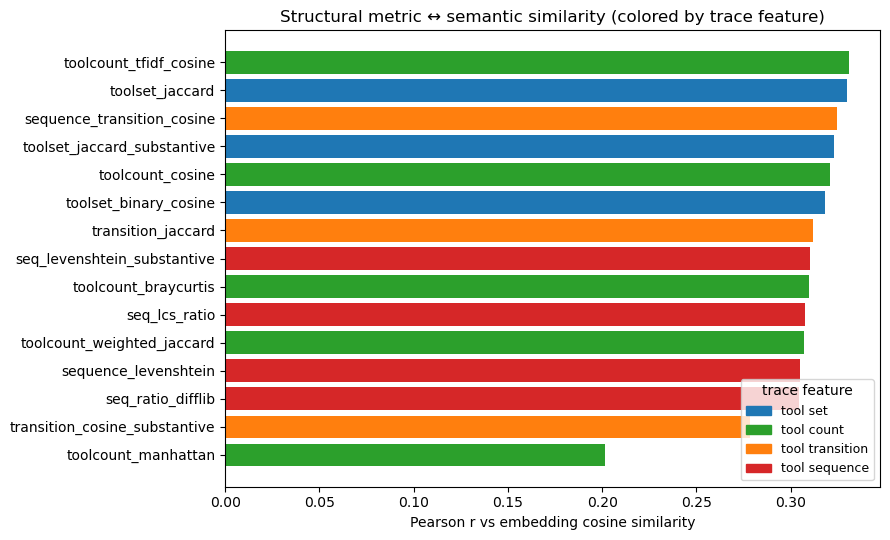

In [11]:
from difflib import SequenceMatcher
OVERHEAD = {"ToolSearch", "StructuredOutput"}   # ubiquitous scaffolding tools

# ---- per-trace representations (reuses vocab, vidx, B, C, cos from section 7) ----
seqs       = list(dfe.tool_sequence)
sets       = [set(s) for s in seqs]
sub_seqs   = [tuple(t for t in s if t not in OVERHEAD) for s in seqs]
sub_sets   = [set(s) for s in sub_seqs]
trans_sets = [set(zip(s, s[1:])) for s in seqs]

# IDF-weighted count vectors (down-weight tools that appear in many traces)
Ntr = len(dfe)
dftool = Counter()
for s in seqs: dftool.update(set(s))
idf = np.array([np.log((Ntr + 1) / (dftool[t] + 1)) + 1 for t in vocab])
TF = C * idf

# transition (bigram) count vectors: full and substantive
def make_trans(seq_list):
    bv = sorted({(a, b) for s in seq_list for a, b in zip(s, s[1:])})
    bi = {bg: i for i, bg in enumerate(bv)}
    M = np.zeros((len(seq_list), max(len(bv), 1)))
    for r, s in enumerate(seq_list):
        for a, b in zip(s, s[1:]): M[r, bi[(a, b)]] += 1
    return M
T, SUBT = make_trans(seqs), make_trans(sub_seqs)

# ---- helpers ----
def jaccard(a, b):
    if not a and not b: return 1.0
    u = len(a | b); return len(a & b) / u if u else 0.0
def levenshtein(a, b):
    m, k = len(a), len(b)
    if m == 0 or k == 0: return max(m, k)
    prev = list(range(k + 1))
    for i in range(1, m + 1):
        cur = [i] + [0] * k
        for j in range(1, k + 1):
            cur[j] = min(prev[j] + 1, cur[j-1] + 1, prev[j-1] + (a[i-1] != b[j-1]))
        prev = cur
    return prev[k]
def lev_sim(a, b):
    ml = max(len(a), len(b)); return 1 - levenshtein(a, b) / ml if ml else 1.0
def lcs_sim(a, b):
    la, lb = len(a), len(b)
    if la == 0 or lb == 0: return 1.0 if la == lb else 0.0
    prev = [0] * (lb + 1)
    for i in range(1, la + 1):
        cur = [0] * (lb + 1)
        for j in range(1, lb + 1):
            cur[j] = prev[j-1] + 1 if a[i-1] == b[j-1] else max(prev[j], cur[j-1])
        prev = cur
    return 2 * prev[lb] / (la + lb)
def wjaccard(a, b):
    mn, mx = np.minimum(a, b).sum(), np.maximum(a, b).sum()
    return float(mn / mx) if mx > 0 else 1.0
def bray_sim(a, b):
    d = (a + b).sum(); return 1 - float(np.abs(a - b).sum()) / d if d > 0 else 1.0

ORIG = {"sequence_transition_cosine", "toolset_jaccard", "toolcount_cosine",
        "toolset_binary_cosine", "sequence_levenshtein", "toolcount_manhattan"}
metrics = {
    "sequence_transition_cosine":     lambda i, j: cos(T[i], T[j]),
    "toolset_jaccard":                lambda i, j: jaccard(sets[i], sets[j]),
    "toolcount_cosine":               lambda i, j: cos(C[i], C[j]),
    "toolset_binary_cosine":          lambda i, j: cos(B[i], B[j]),
    "sequence_levenshtein":           lambda i, j: lev_sim(seqs[i], seqs[j]),
    "toolcount_manhattan":            lambda i, j: 1.0 / (1.0 + float(np.abs(C[i] - C[j]).sum())),
    "seq_ratio_difflib":              lambda i, j: SequenceMatcher(None, seqs[i], seqs[j]).ratio(),
    "seq_lcs_ratio":                  lambda i, j: lcs_sim(seqs[i], seqs[j]),
    "transition_jaccard":             lambda i, j: jaccard(trans_sets[i], trans_sets[j]),
    "toolcount_tfidf_cosine":         lambda i, j: cos(TF[i], TF[j]),
    "toolcount_weighted_jaccard":     lambda i, j: wjaccard(C[i], C[j]),
    "toolcount_braycurtis":           lambda i, j: bray_sim(C[i], C[j]),
    "toolset_jaccard_substantive":    lambda i, j: jaccard(sub_sets[i], sub_sets[j]),
    "seq_levenshtein_substantive":    lambda i, j: lev_sim(sub_seqs[i], sub_seqs[j]),
    "transition_cosine_substantive":  lambda i, j: cos(SUBT[i], SUBT[j]),
}

vals = {k: [] for k in metrics}
ep = []
for i in range(n):
    for j in range(i + 1, n):
        ep.append(S[i, j])
        for k, fn in metrics.items(): vals[k].append(fn(i, j))
ep = np.array(ep)
FAMILY = {
    "toolset_jaccard": "tool set", "toolset_binary_cosine": "tool set",
    "toolset_jaccard_substantive": "tool set",
    "toolcount_cosine": "tool count", "toolcount_manhattan": "tool count",
    "toolcount_tfidf_cosine": "tool count", "toolcount_weighted_jaccard": "tool count",
    "toolcount_braycurtis": "tool count",
    "sequence_transition_cosine": "tool transition", "transition_jaccard": "tool transition",
    "transition_cosine_substantive": "tool transition",
    "sequence_levenshtein": "tool sequence", "seq_ratio_difflib": "tool sequence",
    "seq_lcs_ratio": "tool sequence", "seq_levenshtein_substantive": "tool sequence",
}
FCOLOR = {"tool set": "tab:blue", "tool count": "tab:green",
          "tool transition": "tab:orange", "tool sequence": "tab:red"}
res = pd.DataFrame([
    dict(metric=k, family=FAMILY[k], pearson_r=pearsonr(ep, np.array(v))[0],
         spearman_r=spearmanr(ep, np.array(v))[0], original=(k in ORIG))
    for k, v in vals.items()
]).sort_values("pearson_r", ascending=False).reset_index(drop=True)
display(res.round(3))
best = res.iloc[0]
print(f"\nBest indicator: {best.metric}  [{best.family}]  "
      f"(Pearson r = {best.pearson_r:.3f}, Spearman = {best.spearman_r:.3f})")
print(f"Best of the ORIGINAL six: {res[res.original].iloc[0].metric} "
      f"(r = {res[res.original].iloc[0].pearson_r:.3f})")
print("\nBest metric per trace feature:")
for fam in ["tool set", "tool count", "tool transition", "tool sequence"]:
    sub = res[res.family == fam].iloc[0]
    print(f"  {fam:16s}: {sub.metric:32s} r = {sub.pearson_r:.3f}")

plt.figure(figsize=(9, 5.5))
order = res[::-1]
plt.barh(order.metric, order.pearson_r, color=[FCOLOR[f] for f in order.family])
from matplotlib.patches import Patch
plt.legend(handles=[Patch(color=c, label=f) for f, c in FCOLOR.items()],
           loc="lower right", fontsize=9, title="trace feature")
plt.xlabel("Pearson r vs embedding cosine similarity")
plt.title("Structural metric ↔ semantic similarity (colored by trace feature)")
plt.tight_layout(); plt.show()
